# Structural Backfire Analysis

For each run, we:
1. Identify the targeted node from the step-20000 GEXF (`target=True`)
2. Compute its structural position: in-degree, betweenness centrality, local clustering coefficient, PageRank, eigenvector centrality
3. Measure the backfire effect: Δopposite − Δtarget post-share (late window minus pre-intervention baseline)
4. Scatter-plot each structural metric against backfire magnitude with Spearman correlation

Runs with no valid target (empty moderate-influencer pool) are silently excluded.

**Note on eigenvector centrality:** computed as the left eigenvector of the directed adjacency matrix (hub score). Falls back to NaN if power iteration fails to converge.

In [17]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import xml.etree.ElementTree as ET
from scipy import stats

RESULTS_DIR = "./results"
BINS = ["bin_0", "bin_1", "bin_2", "bin_3", "bin_4"]

# step window just before intervention = baseline; end of simulation = outcome
PRE_RANGE  = (19000, 20000)
POST_RANGE = (39000, 40000)

In [18]:
# ---------------------------------------------------------------------------
# GEXF parsing: return (DiGraph, target_node_id)
# Reads node attribute 'target' (boolean) written by GraphVisualize.java.
# ---------------------------------------------------------------------------
def parse_gexf_for_target(fpath):
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]

        # build attribute-id -> title map from <attributes class="node">
        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')

        G = nx.DiGraph()
        target_node = None

        for node in root.findall(".//node"):
            nid = node.get('id')
            G.add_node(nid)
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    target_node = nid

        for edge in root.findall(".//edge"):
            G.add_edge(edge.get('source'), edge.get('target'))

        return G, target_node
    except Exception as e:
        print(f"  [WARN] GEXF parse failed ({fpath}): {e}")
        return None, None


def get_target_structural_metrics(G, target_id):
    """Node-level structural indices for the targeted agent."""
    if G is None or target_id is None or target_id not in G:
        return {}

    in_degree = G.in_degree(target_id)

    # exact betweenness on ~1000-node graph; takes ~1-2 s per run
    bc_all = nx.betweenness_centrality(G, normalized=True)
    betweenness = bc_all.get(target_id, np.nan)

    G_und = G.to_undirected()
    clustering = nx.clustering(G_und, target_id)

    # PageRank: robust on directed graphs; alpha=0.85 is the standard damping factor
    pr_all = nx.pagerank(G, alpha=0.85, max_iter=200)
    pagerank = pr_all.get(target_id, np.nan)

    # Eigenvector centrality on directed graph (left eigenvector = hub score).
    # Can fail to converge on sparse/disconnected graphs; fall back to NaN.
    try:
        ec_all = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
        eigenvector = ec_all.get(target_id, np.nan)
    except nx.PowerIterationFailedConvergence:
        eigenvector = np.nan

    return {
        'in_degree':   in_degree,
        'betweenness': betweenness,
        'clustering':  clustering,
        'pagerank':    pagerank,
        'eigenvector': eigenvector,
    }

In [19]:
# ---------------------------------------------------------------------------
# Backfire effect per run
# backfire_effect = (Δopposite_share) − (Δtarget_share)
# Positive value  => opposite side grew more = backfire
# ---------------------------------------------------------------------------
def compute_backfire_effect(run_dir, target_sign, pre_range, post_range):
    post_dir = os.path.join(run_dir, "posts")
    files = glob.glob(os.path.join(post_dir, "post_result_*.csv"))
    if not files:
        return np.nan

    dfs = []
    for f in files:
        try:
            dfs.append(pd.read_csv(f))
        except Exception:
            pass
    if not dfs:
        return np.nan

    df = pd.concat(dfs, ignore_index=True).sort_values('step')

    # relative bin assignment
    if target_sign > 0:
        target_bins   = ["bin_3", "bin_4"]
        opposite_bins = ["bin_0", "bin_1"]
    else:
        target_bins   = ["bin_0", "bin_1"]
        opposite_bins = ["bin_3", "bin_4"]

    def mean_share(df, bins, step_range):
        mask = (df['step'] >= step_range[0]) & (df['step'] <= step_range[1])
        sub = df[mask].copy()
        if sub.empty:
            return np.nan
        total = sub[BINS].sum(axis=1).replace(0, np.nan)
        return (sub[bins].sum(axis=1) / total).mean()

    target_pre    = mean_share(df, target_bins,   pre_range)
    target_post   = mean_share(df, target_bins,   post_range)
    opposite_pre  = mean_share(df, opposite_bins, pre_range)
    opposite_post = mean_share(df, opposite_bins, post_range)

    delta_target   = target_post   - target_pre
    delta_opposite = opposite_post - opposite_pre

    return delta_opposite - delta_target

In [20]:
# ---------------------------------------------------------------------------
# Main data collection loop
# ---------------------------------------------------------------------------
records = []
run_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "run_*")))
print(f"Found {len(run_dirs)} run directories.")

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m:
        continue
    seed        = int(m.group(1))
    target_sign = float(m.group(2))

    # locate step_20000 GEXF
    gexf_files = glob.glob(os.path.join(run_dir, "GEXF", "*", "step_20000.gexf"))
    if not gexf_files:
        print(f"  [SKIP] {dirname}: no step_20000 GEXF")
        continue

    print(f"Processing {dirname} ...", end=" ")
    G, target_id = parse_gexf_for_target(gexf_files[0])
    if target_id is None:
        print("no target node (pool was empty, run excluded)")
        continue

    struct = get_target_structural_metrics(G, target_id)
    backfire = compute_backfire_effect(run_dir, target_sign, PRE_RANGE, POST_RANGE)

    records.append({
        'run_id':          dirname,
        'seed':            seed,
        'target_sign':     target_sign,
        'target_id':       target_id,
        'backfire_effect': backfire,
        **struct,
    })
    print(f"target={target_id}, pr={struct.get('pagerank', np.nan):.4f}, "
          f"ev={struct.get('eigenvector', np.nan):.4f}, backfire={backfire:.4f}")

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} valid runs.")
print(df[['seed', 'target_sign', 'in_degree', 'betweenness', 'clustering',
          'pagerank', 'eigenvector', 'backfire_effect']].describe())

Found 10 run directories.
Processing run_0_dir_-1.0 ... target=15, pr=0.0029, ev=0.0000, backfire=0.0992
Processing run_0_dir_1.0 ... target=15, pr=0.0029, ev=0.0000, backfire=-0.0564
Processing run_1_dir_-1.0 ... target=5, pr=0.0120, ev=0.0001, backfire=0.1376
Processing run_1_dir_1.0 ... target=5, pr=0.0120, ev=0.0001, backfire=-0.0955
Processing run_2_dir_-1.0 ... target=27, pr=0.0013, ev=0.0000, backfire=-0.2030
Processing run_2_dir_1.0 ... target=27, pr=0.0013, ev=0.0000, backfire=0.1048
Processing run_3_dir_-1.0 ... target=38, pr=0.0051, ev=0.0000, backfire=-0.0172
Processing run_3_dir_1.0 ... target=38, pr=0.0051, ev=0.0000, backfire=0.0295
Processing run_4_dir_-1.0 ... target=12, pr=0.0042, ev=0.0000, backfire=-0.0220
Processing run_4_dir_1.0 ... target=12, pr=0.0042, ev=0.0000, backfire=0.0221

Collected 10 valid runs.
            seed  target_sign   in_degree  betweenness  clustering   pagerank  \
count  10.000000    10.000000   10.000000    10.000000   10.000000  10.000000  

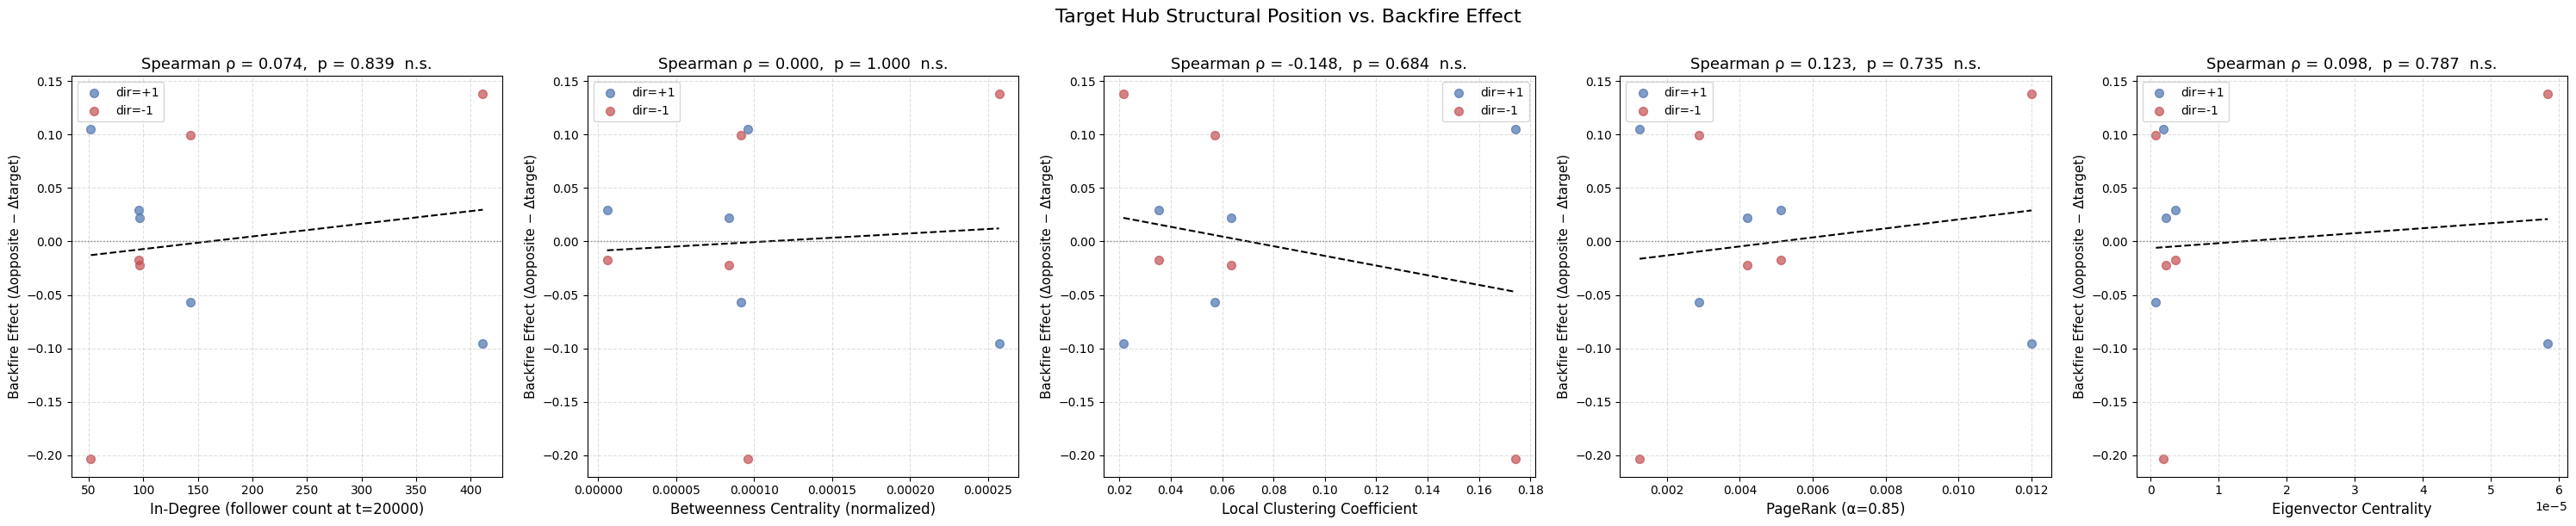

Figure saved to results/summary/structural_backfire.png


In [21]:
# ---------------------------------------------------------------------------
# Scatter plots: structural metric (x) vs backfire effect (y)
# One panel per metric; Spearman r used (distribution-free, robust to outliers)
# ---------------------------------------------------------------------------
STRUCTURAL_METRICS = [
    ('in_degree',   'In-Degree (follower count at t=20000)'),
    ('betweenness', 'Betweenness Centrality (normalized)'),
    ('clustering',  'Local Clustering Coefficient'),
    ('pagerank',    'PageRank (α=0.85)'),
    ('eigenvector', 'Eigenvector Centrality'),
]

df_plot = df.dropna(subset=['backfire_effect'])

fig, axes = plt.subplots(1, 5, figsize=(30, 6))

# color by target direction so we can spot direction-specific confounds
colors = {1.0: '#4c72b0', -1.0: '#c44e52'}

for ax, (metric, xlabel) in zip(axes, STRUCTURAL_METRICS):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['backfire_effect'].values

    for sign, c in colors.items():
        mask = sub['target_sign'] == sign
        label = f'dir={sign:+.0f}'
        ax.scatter(sub.loc[mask, metric], sub.loc[mask, 'backfire_effect'],
                   color=c, alpha=0.7, s=50, label=label)

    # OLS regression line (visual guide)
    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    # Spearman correlation
    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Backfire Effect (Δopposite − Δtarget)', fontsize=11)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Target Hub Structural Position vs. Backfire Effect', fontsize=16, y=1.01)
plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, "summary"), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, "summary", "structural_backfire.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/structural_backfire.png")

In [22]:
# ---------------------------------------------------------------------------
# Optional: save the per-run metrics table for further analysis
# ---------------------------------------------------------------------------
out_path = os.path.join(RESULTS_DIR, "summary", "structural_backfire_table.csv")
df.to_csv(out_path, index=False)
print(f"Per-run table saved to {out_path}")
df

Per-run table saved to ./results/summary/structural_backfire_table.csv


,run_id,seed,target_sign,target_id,backfire_effect,in_degree,betweenness,clustering,pagerank,eigenvector
0,run_0_dir_-1.0,0,-1.0,15,0.099210,143,0.000092,0.057180,0.002883,7.681522e-07
1,run_0_dir_1.0,0,1.0,15,-0.056440,143,0.000092,0.057180,0.002883,7.681522e-07
2,run_1_dir_-1.0,1,-1.0,5,0.137573,411,0.000257,0.021535,0.012002,5.833699e-05
3,run_1_dir_1.0,1,1.0,5,-0.095483,411,0.000257,0.021535,0.012002,5.833699e-05
4,run_2_dir_-1.0,2,-1.0,27,-0.202957,52,0.000096,0.174167,0.001253,1.848589e-06
5,run_2_dir_1.0,2,1.0,27,0.104813,52,0.000096,0.174167,0.001253,1.848589e-06
6,run_3_dir_-1.0,3,-1.0,38,-0.017220,96,0.000006,0.035223,0.005135,3.575610e-06
7,run_3_dir_1.0,3,1.0,38,0.029511,96,0.000006,0.035223,0.005135,3.575610e-06
8,run_4_dir_-1.0,4,-1.0,12,-0.021952,97,0.000084,0.063564,0.004210,2.282782e-06
9,run_4_dir_1.0,4,1.0,12,0.022061,97,0.000084,0.063564,0.004210,2.282782e-06
